<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/Project/Model_Code/TEST1_retrainLGBM_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title
# TEST 1
#Catboost - cls
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/Catboost_firstiteration_classifier.pkl
# Catboost - reg
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/Catboost_firstiteration_regressor.cbm

#LGBM - cls
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/lightgbm_classifier_model.txt
#LGBM - reg
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/lightgbm_regressor_model.txt

# TEST 2
#Catboost
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Raw vs log, preprocessing v2, encoded categorical/cat_log_encoded_prepv2.pkl
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Raw vs log, preprocessing v2, encoded categorical/cat_raw_encoded_prepv2.pkl

#LGBM
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Raw vs log, preprocessing v2, encoded categorical/lgb_log_encoded_prepv2.pkl
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Raw vs log, preprocessing v2, encoded categorical/lgb_raw_encoded_prepv2.pkl

# TEST 3
# Catboost
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Engineered features, no encoded cat, preprocessing v2/catboost_noencoding_engfeat_prepv2_tuned.pkl

#LGBM
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/CatBoost + LGBM Tests/Engineered features, no encoded cat, preprocessing v2/lightgbm_noencoding_engfeat_prepv2_tuned.pkl

# TEST 4
# Catboost - cls
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_classifier.pkl
# Catboost - reg
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_regressor_single10k.pkl

# LGBM - cls
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_classifier.pkl
# LGBM - reg
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_regressor_single-2.pkl

# Threshold config test 4
/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/threshold_config.json

In [ ]:
!pip install catboost
!pip install lightgbm

need to retrain first lgbm classifier

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Mount Google Drive
drive.mount('/content/drive')

print("="*80)
print("RETRAINING LGBM CLASSIFIER - 3-CLASS LOS PREDICTION")
print("="*80)

# Load data
path = "/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather"
print(f"\nLoading data from: {path}")
data = pd.read_feather(path)
print(f"✓ Loaded {len(data):,} samples")

# Clean data
data['length_of_stay'] = pd.to_numeric(data['length_of_stay'], errors='coerce')
data = data.dropna(subset=['length_of_stay'])
data = data[data['zip_code'] != 'OOS']
print(f"✓ After cleaning: {len(data):,} samples")

# Define features
categorical_cols = [
    'health_service_area', 'zip_code', 'hospital_county', 'age_group',
    'gender', 'race', 'ethnicity', 'admission_type', 'apr_mortality_risk',
    'apr_med_surg_desc', 'ccsr_dx_code', 'ccsr_px_code', 'payment_type'
]
numeric_cols = ["facility_id", "apr_drg_code", "apr_mdc_code",
                "apr_severity_code", 'num_payment_types']
feature_cols = categorical_cols + numeric_cols

# Convert categorical columns to category type
for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].astype('category')

# Convert numeric columns to proper numeric types
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        # Fill NaN with 0 or median depending on column
        if data[col].isna().sum() > 0:
            if col == 'num_payment_types':
                data[col] = data[col].fillna(0)
            else:
                data[col] = data[col].fillna(data[col].median())
        data[col] = data[col].astype('float64')

print(f"\n✓ Converted {len(numeric_cols)} numeric columns to float64")

# Create 3-class target
print("\nCreating 3-class target (short/medium/long)...")
data['los_3class'] = pd.qcut(data['length_of_stay'], q=3,
                              labels=['short', 'medium', 'long']).astype('category')

# Check class distribution
print("\nClass distribution:")
print(data['los_3class'].value_counts())
print(f"\nPercentages:")
print(data['los_3class'].value_counts(normalize=True) * 100)

# Prepare features and target
X = data[feature_cols]
y = data['los_3class']

# Train-test split
print("\nSplitting data (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Train LightGBM Classifier
print("\n" + "="*80)
print("TRAINING LGBM CLASSIFIER")
print("="*80)

model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("\nModel parameters:")
print(f"  Objective: multiclass (3 classes)")
print(f"  N estimators: 500")
print(f"  Learning rate: 0.03")
print(f"  Num leaves: 63")
print(f"  Subsample: 0.8")
print(f"  Colsample_bytree: 0.8")

model.fit(X_train, y_train)
print("\n✓ Training complete")

# Make predictions
print("\nMaking predictions on test set...")
y_pred = model.predict(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("\n" + "="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(f"\nAccuracy: {acc:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print("\n" + "="*80)
print("TOP 20 FEATURE IMPORTANCES")
print("="*80)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))

# Save model
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save as pickle (includes full model object)
pkl_path = '/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/lightgbm_classifier_3class.pkl'
joblib.dump(model, pkl_path)
print(f"✓ Saved pickle to: {pkl_path}")

# Save as txt (LightGBM format - for compatibility)
txt_path = '/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/first iterations (regressor and classifier)/lightgbm_classifier_3class.txt'
model.booster_.save_model(txt_path)
print(f"✓ Saved booster to: {txt_path}")

# Also save to downloads for easy access
joblib.dump(model, '/content/downloads/lightgbm_classifier_3class.pkl')
print(f"✓ Saved copy to: /content/downloads/lightgbm_classifier_3class.pkl")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"\nFinal Model Summary:")
print(f"  Type: 3-class classifier (short/medium/long)")
print(f"  Algorithm: LightGBM")
print(f"  Features: {len(feature_cols)}")
print(f"  Test Accuracy: {acc:.4f}")
print(f"  Test F1 (Macro): {f1_macro:.4f}")
print(f"  Test F1 (Weighted): {f1_weighted:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RETRAINING LGBM CLASSIFIER - 3-CLASS LOS PREDICTION

Loading data from: /content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather
✓ Loaded 4,238,636 samples
✓ After cleaning: 4,110,661 samples

✓ Converted 5 numeric columns to float64

Creating 3-class target (short/medium/long)...

Class distribution:
los_3class
short     1604537
medium    1307254
long      1198870
Name: count, dtype: int64

Percentages:
los_3class
short     39.033552
medium    31.801552
long      29.164896
Name: proportion, dtype: float64

Splitting data (80/20)...
Training set: 3,288,528 samples
Test set: 822,133 samples

TRAINING LGBM CLASSIFIER

Model parameters:
  Objective: multiclass (3 classes)
  N estimators: 500
  Learning rate: 0.03
  Num leaves: 63
  Subsample: 0.8
  Colsample_bytree: 0.8

✓ Training complete

Making predictions on test set...

MODEL PERFORMANCE

Accuracy: 

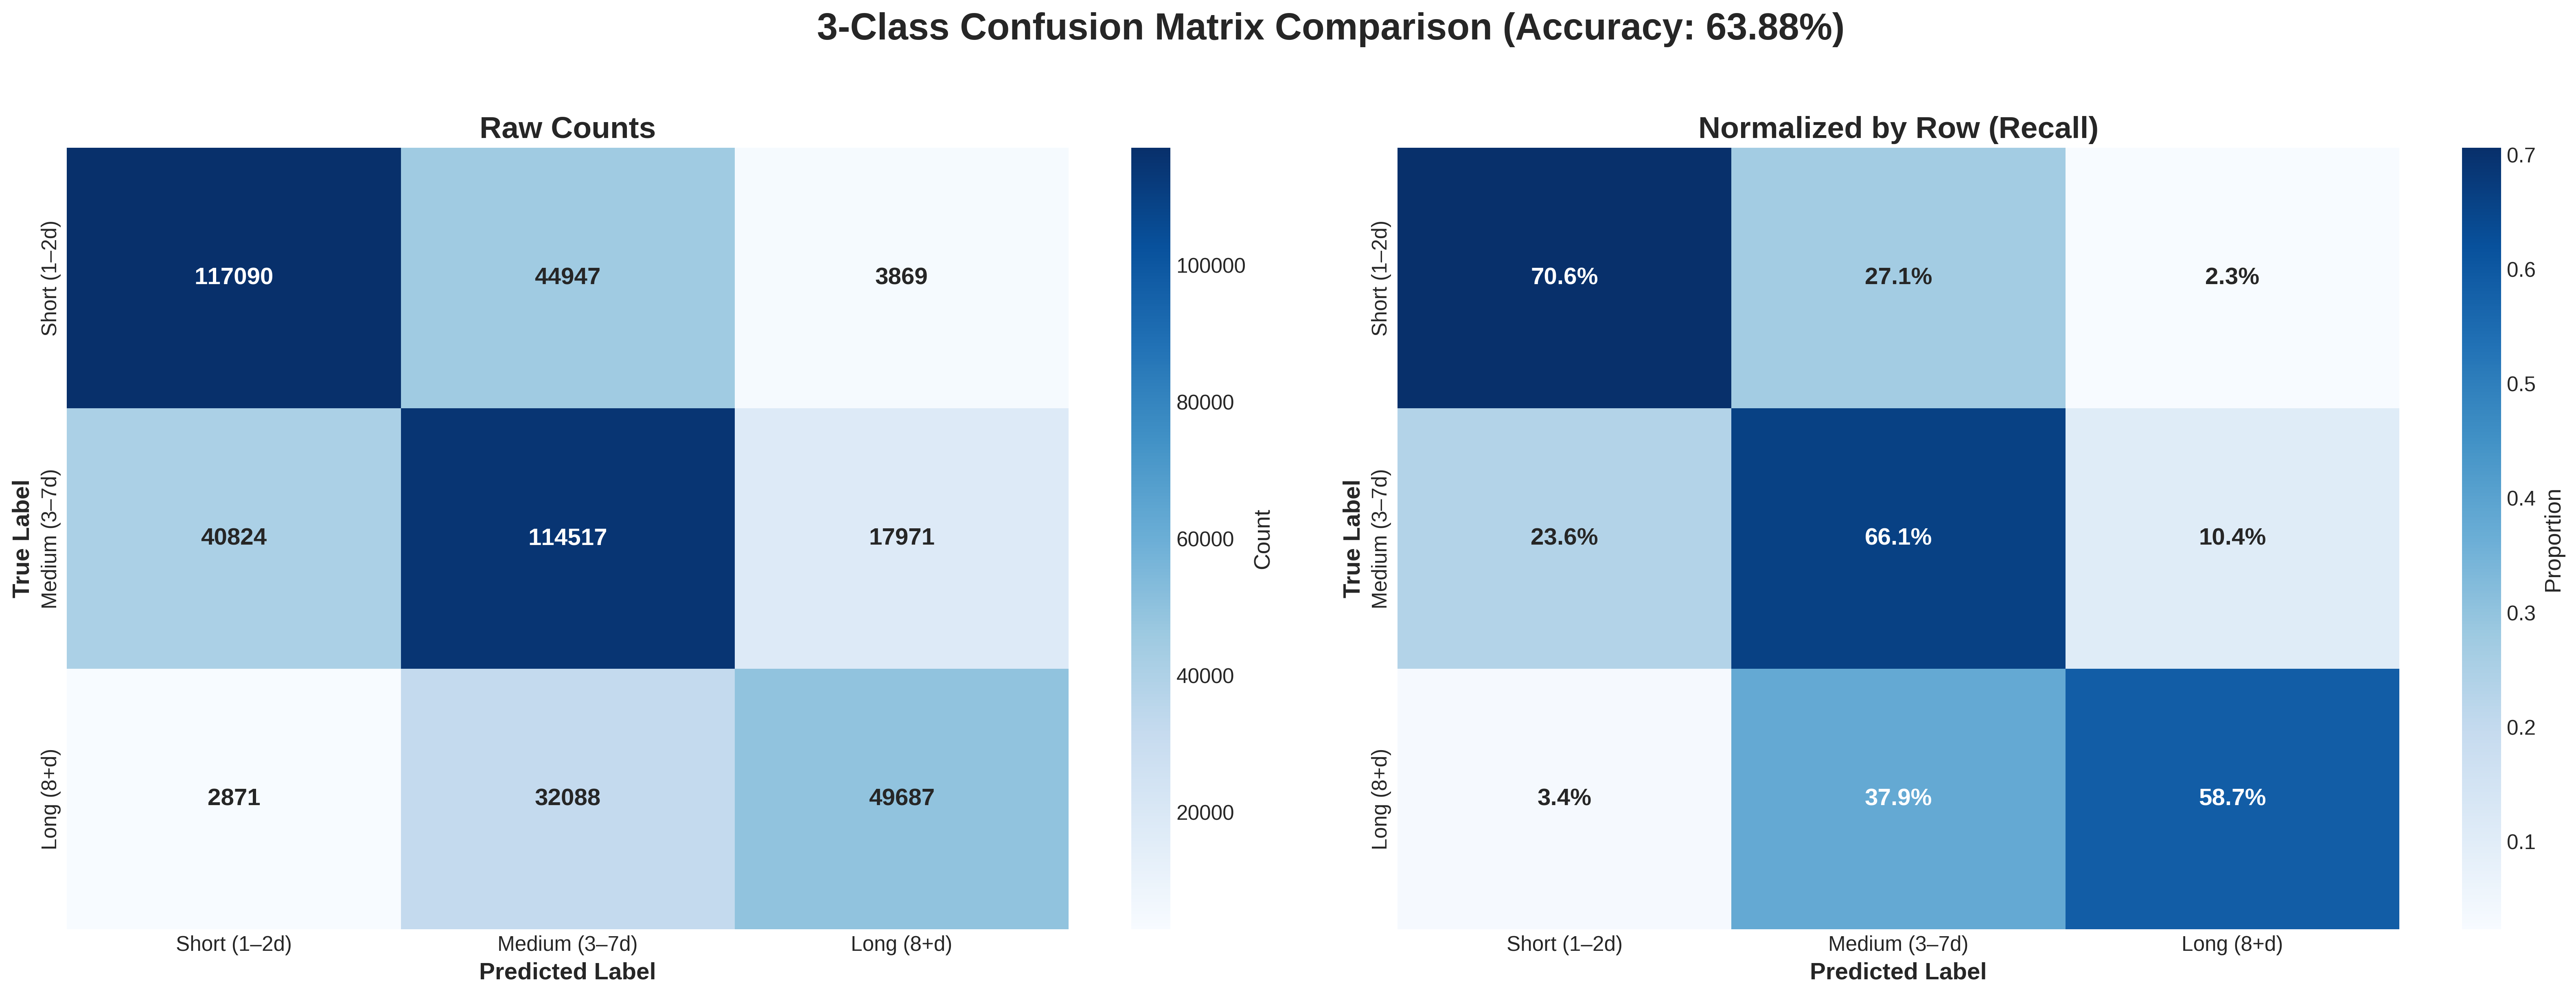

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================================
# CONFUSION MATRIX VALUES
# =====================================================================================
cm = np.array([
    [117090,  44947,   3869],   # short
    [ 40824, 114517,  17971],   # medium
    [  2871,  32088,  49687]    # long
])

# Normalize by row (recall)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

class_names = ["Short (1–2d)", "Medium (3–7d)", "Long (8+d)"]

# =====================================================================================
# PLOT CONFIGURATION
# =====================================================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

plt.suptitle("3-Class Confusion Matrix Comparison (Accuracy: 63.88%)",
             fontsize=22, fontweight="bold", y=1.02)

# =====================================================================================
# RAW COUNTS HEATMAP
# =====================================================================================
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "weight": "bold"}, ax=axes[0], cbar_kws={"label": "Count"})

axes[0].set_title("Raw Counts", fontsize=18, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=14, fontweight="bold")
axes[0].set_ylabel("True Label", fontsize=14, fontweight="bold")

# =====================================================================================
# NORMALIZED HEATMAP
# =====================================================================================
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "weight": "bold"}, ax=axes[1], cbar_kws={"label": "Proportion"})

axes[1].set_title("Normalized by Row (Recall)", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=14, fontweight="bold")
axes[1].set_ylabel("True Label", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
